In [14]:
import pandas as pd
import geopandas as gpd
import numpy as np
import seaborn as sns

# Seasonal Scope
- Original paper uses only summer months, because most incidents happen during the summer.
- However, this may not be the case for Essex. The paper references sources in which it indicates that an alternative approach is to make sub-models for each season. We must check if this is necessary.

In [15]:
incidents_df = pd.read_csv("./data/bronze/incidents/OutdoorFIres_2009_2025.csv")
incidents_df["CallDateID"] = pd.to_datetime(incidents_df["CallDateID"])

incidents_df["Year"] = incidents_df["CallDateID"].dt.year
incidents_df["Month"] = incidents_df["CallDateID"].dt.month

temp = incidents_df[["Year", "Month"]].copy()

def seasons(x):
    if x in [12, 1, 2]:
        return "WINTER"
    elif x in [3, 4, 5]:
        return "SPRING"
    elif x in [6, 7, 8]:
        return "SUMMER"
    elif x in [9, 10, 11]:
        return "FALL"
    else:
        return "BRUH"


temp["Season"] = temp["Month"].apply(seasons)

C:\Users\rcorr\AppData\Local\Temp\ipykernel_7872\1198723050.py:2: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  incidents_df["CallDateID"] = pd.to_datetime(incidents_df["CallDateID"])


In [16]:
incidents_df["Year"].min(), incidents_df["Year"].max()

(np.int32(2009), np.int32(2025))

In [17]:
temp["Season"].value_counts() / len(temp)

Season
SUMMER    0.461324
SPRING    0.244064
FALL      0.218923
WINTER    0.075690
Name: count, dtype: float64

In [27]:
season_year_counts = temp.groupby(["Season", "Year"]).size().unstack(fill_value=0)
season_year_counts

Year,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
Season,,,,,,,,,,,,,,,,,
FALL,986,292,563,380,207,227,239,588,364,380,408,294,305,309,304,298,439
SPRING,510,524,771,433,277,326,353,317,647,260,507,486,419,413,281,221,594
SUMMER,1144,1125,658,398,744,549,774,670,636,1123,745,835,304,1727,653,661,1126
WINTER,41,109,172,199,127,99,99,144,146,161,184,138,93,150,140,136,138


In [41]:
pct_season_year_counts = 100 * season_year_counts / season_year_counts.sum(axis = 0)
pct_season_year_counts

Year,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
Season,,,,,,,,,,,,,,,,,
FALL,36.777322,14.243902,26.016636,26.950355,15.276753,18.900916,16.313993,34.205934,20.301171,19.750520,22.125813,16.771249,27.207850,11.889188,22.060958,22.644377,19.111885
SPRING,19.022753,25.560976,35.628466,30.709220,20.442804,27.144047,24.095563,18.440954,36.084774,13.513514,27.494577,27.723902,37.377342,15.890727,20.391872,16.793313,25.859817
SUMMER,42.670645,54.878049,30.406654,28.226950,54.907749,45.711907,52.832765,38.976149,35.471277,58.367983,40.401302,47.632630,27.118644,66.448634,47.387518,50.227964,49.020461
WINTER,1.529280,5.317073,7.948244,14.113475,9.372694,8.243131,6.757679,8.376963,8.142777,8.367983,9.978308,7.872219,8.296164,5.771451,10.159652,10.334347,6.007836


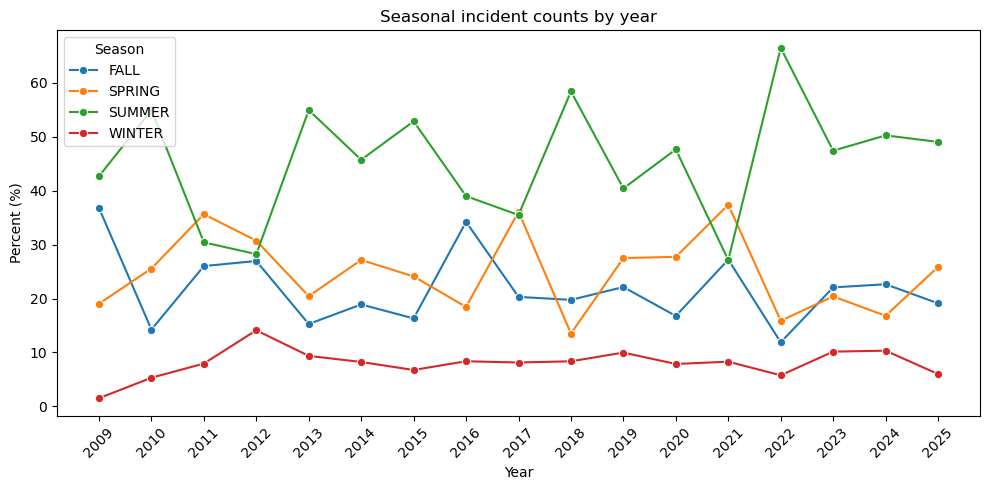

In [46]:
import matplotlib.pyplot as plt

df_long = pct_season_year_counts.reset_index().melt(id_vars="Season", var_name="Year", value_name="Percent (%)")
df_long["Year"] = df_long["Year"].astype(int)

plt.figure(figsize=(10,5))
sns.lineplot(data=df_long, x="Year", y="Percent (%)", hue="Season", marker="o")
plt.title("Seasonal incident counts by year")
plt.xticks(sorted(df_long["Year"].unique()), rotation=45)
plt.tight_layout()
plt.show()

In conclusion, it would be wrong to exclude the spring and fall months, since these three account for 93% of all incidents.

# Nans analysis

In [20]:
spring = pd.read_csv("./data/silver/model_datasets/dataset_clean_spring.csv")
summer = pd.read_csv("./data/silver/model_datasets/dataset_clean_summer.csv")
fall = pd.read_csv("./data/silver/model_datasets/dataset_clean_fall.csv")

KeyboardInterrupt: 

In [ ]:
spring.describe()

,elevation,slope,aspect,d_roads,d_rivers,d_activity,tas,tasmax,tasmin,rainfall,sfcWind,hurs,ndvi,label
count,3.851135e+06,3.817675e+06,3.817675e+06,3.851135e+06,3.851135e+06,3.851135e+06,3.744851e+06,3.744851e+06,3.744851e+06,3.744851e+06,3.744851e+06,3.744851e+06,3.821780e+06,577713.000000
mean,5.223663e+01,2.098766e+00,1.760254e+02,1.782378e-01,6.817898e-01,3.637166e-02,9.897477e+00,1.418229e+01,4.743139e+00,3.335385e+01,3.977889e+00,7.873035e+01,6.335024e-01,0.750026
std,3.222541e+01,1.484300e+00,1.009102e+02,1.847498e-01,5.110058e-01,1.008373e-01,2.630796e-01,2.903725e-01,4.242869e-01,1.849704e+00,2.370731e-01,7.349807e-01,7.502595e-02,1.042871
min,-1.140696e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,9.155728e+00,1.288571e+01,3.733323e+00,2.780735e+01,2.983809e+00,7.547298e+01,-2.733085e-02,0.000000
25%,2.475444e+01,1.071924e+00,9.141675e+01,4.242641e-02,2.683282e-01,0.000000e+00,9.720851e+00,1.400823e+01,4.421867e+00,3.202391e+01,3.840004e+00,7.826727e+01,6.057099e-01,0.000000
50%,5.300000e+01,1.771499e+00,1.752872e+02,1.236932e-01,5.894065e-01,0.000000e+00,9.899680e+00,1.419816e+01,4.717377e+00,3.348261e+01,3.967282e+00,7.877897e+01,6.475081e-01,0.000000
75%,7.707836e+01,2.734282e+00,2.629663e+02,2.563201e-01,9.990495e-01,3.000000e-02,1.007496e+01,1.435980e+01,5.032806e+00,3.465560e+01,4.088809e+00,7.921995e+01,6.806812e-01,2.000000
max,1.559932e+02,2.169229e+01,3.599999e+02,2.151023e+00,3.789512e+00,1.623884e+00,1.100715e+01,1.527510e+01,6.063400e+00,4.037873e+01,5.102995e+00,8.079549e+01,8.105581e-01,3.000000


In [ ]:
(spring.isna().sum() / len(spring)) * 100

elevation      0.000000
slope          0.868835
aspect         0.868835
d_roads        0.000000
d_rivers       0.000000
d_activity     0.000000
tas            2.759810
tasmax         2.759810
tasmin         2.759810
rainfall       2.759810
sfcWind        2.759810
hurs           2.759810
ndvi           0.762243
label         84.998890
dtype: float64

In [ ]:
(summer.isna().sum() / len(summer)) * 100


elevation      0.000000
slope          0.868835
aspect         0.868835
d_roads        0.000000
d_rivers       0.000000
d_activity     0.000000
tas            2.759810
tasmax         2.759810
tasmin         2.759810
rainfall       2.759810
sfcWind        2.759810
hurs           2.759810
ndvi           0.759412
label         78.943247
dtype: float64

In [ ]:
(fall.isna().sum() / len(fall)) * 100


elevation      0.000000
slope          0.868835
aspect         0.868835
d_roads        0.000000
d_rivers       0.000000
d_activity     0.000000
tas            2.759810
tasmax         2.759810
tasmin         2.759810
rainfall       2.759810
sfcWind        2.759810
hurs           2.759810
ndvi           0.771123
label         85.478515
dtype: float64